<div style="position: relative; width: 100vw; margin-left: calc(-50vw + 50%); left: 50%; transform: translateX(-50%); line-height: 0;">
    <img src="https://raw.githubusercontent.com/pamelaFranco/vision_computador_UNAB/main/Imagenes/banner.png"
         style="width: 100vw; max-width: none; height: auto; display: block; border: none;">
    <div style="width: 100vw; height: 8px; background-color: #003366;"></div>
</div>

<div style="height: 180px;"></div>

# Curiosidad y Aplicación: El Sistema Visual Humano como un Procesador de Señales

En el contexto del procesamiento digital de señales e imágenes, resulta interesante observar cómo el sistema visual humano realiza operaciones biológicas que son matemáticamente equivalentes a las transformaciones espectrales y al filtrado 2D.

A diferencia de una cámara digital que registra una escena como una matriz de píxeles independientes en el dominio del espacio, la retina y la corteza visual primaria (área V1) realizan una descomposición basada en **frecuencias espaciales** y **orientaciones**.

---

### 0. Fotorreceptores Retinianos: Captura y Muestreo de la Señal (Conos y Bastones)

![Esquema de Fotorreceptores (Conos y Bastones)](https://raw.githubusercontent.com/pamelaFranco/vision_computador_UNAB/main/Imagenes/photoreceptor.jpeg)

La conversión de la señal lumínica continua a impulsos electroquímicos se realiza en la retina mediante dos tipos de fotorreceptores que actúan como sensores espectrales y de intensidad:

* **Conos (Visión Croma / RGB):**
  * Responsables de la visión fotópica (alta iluminación) y de la percepción del color (visión tricromática equivalente a canales RGB).
  * Existen tres tipos de conos definidos por su sensibilidad a distintas longitudes de onda ($\lambda$):
    * **Conos S (Short):** Sensibles a longitudes de onda cortas (~420 nm, espectro azul).
    * **Conos M (Medium):** Sensibles a longitudes de onda medias (~534 nm, espectro verde).
    * **Conos L (Long):** Sensibles a longitudes de onda largas (~564 nm, espectro rojo).
  * Se concentran principalmente en la **fóvea** (centro de la retina) y alimentan predominantemente a la **Vía Parvocelular** para el análisis de color y detalles finos de alta frecuencia espacial.

* **Bastones (Luminancia y Visión Nocturna):**
  * Responsables de la visión escotópica (baja iluminación).
  * Poseen un único fotopigmento (rodopsina), por lo que no captan información cromática (proporcionan una respuesta monocromática / escala de grises de intensidad $I(x,y)$).
  * Tienen una elevada sensibilidad al contraste de brillo y rapidez temporal, alimentando a la **Vía Magnocelular** para procesar la estructura global de la escena, sombras y movimiento.

---

### 1. Transformada de Fourier 2D y el Dominio de la Frecuencia Espacial

Para una imagen continua $f(x,y)$, la Transformada de Fourier bidimensional se define como:

$$F(u,v) = \iint_{-\infty}^{\infty} f(x,y) e^{-i 2\pi (ux + vy)} \,dx\,dy$$

Donde $u$ y $v$ representan las frecuencias espaciales en las direcciones horizontal y vertical, respectivamente. Si bien la Transformada de Fourier global proporciona el contenido espectral de toda la imagen, no preserva la localización espacial de las frecuencias.

---

### 2. Filtrado en la Retina (Diferencia de Gaussianas)

El procesamiento inicial comienza en la retina. Las células ganglionares atenúan la componente continua de la luz (frecuencia espacial cero) y procesan las variaciones de luminancia mediante un filtro de tipo centro-periferia. Este comportamiento se modela mediante una **Diferencia de Gaussianas (DoG)**:

$$DoG(x,y) = \frac{1}{2\pi\sigma_1^2} \exp\left(-\frac{x^2+y^2}{2\sigma_1^2}\right) - \frac{1}{2\pi\sigma_2^2} \exp\left(-\frac{x^2+y^2}{2\sigma_2^2}\right)$$

Este operador actúa como un **filtro pasa-banda**, eliminando bajas frecuencias no informativas y resaltando los cambios bruscos de intensidad (bordes).

---

### 3. Vías Paralelas: Separación en Bandas de Frecuencia

El nervio óptico divide la señal de entrada en dos canales principales de transmisión:

* **Vía Magnocelular (Bajas Frecuencias Espaciales):** Transporta información asociada a componentes de baja frecuencia espacial en el espectro. Proporciona una respuesta rápida sobre la estructura general de la escena, sombras, contraste global y movimiento.
* **Vía Parvocelular (Altas Frecuencias Espaciales):** Transporta componentes de alta frecuencia espacial, encargada del análisis fino de detalles, texturas y bordes definidos.

---

### 4. Corteza Visual Primaria (V1) y Filtros de Gabor

![Corteza V1](https://raw.githubusercontent.com/pamelaFranco/vision_computador_UNAB/main/Imagenes/corteza-V1.png)

Para resolver la limitación de la Transformada de Fourier global (pérdida de información espacial), las neuronas de la corteza V1 realizan un análisis espacio-frecuencia local, equivalente a una **Transformada de Fourier de Tiempo/Espacio Reducido (STFT)** o una representación basada en **Wavelets**.

Las respuestas de las neuronas simples en V1 se modelan mediante **Filtros de Gabor 2D**:

$$\psi(x, y; \lambda, \theta, \varphi, \sigma, \gamma) = \exp\left(-\frac{x'^2 + \gamma^2 y'^2}{2\sigma^2}\right) \cos\left(2\pi \frac{x'}{\lambda} + \varphi\right)$$

Donde las coordenadas rotadas se definen como:

$$x' = x \cos\theta + y \sin\theta$$
$$y' = -x \sin\theta + y \cos\theta$$

**Parámetros del filtro:**
* $\lambda$: Longitud de onda de la componente oscilatoria (inverso de la frecuencia espacial).
* $\theta$: Orientación del filtro (ángulo de preferencia de la neurona).
* $\varphi$: Desfase de la onda senoidal.
* $\sigma$: Desviación estándar de la envolvente gaussiana (determina el tamaño del campo receptivo).
* $\gamma$: Relación de aspecto o elipticidad espacial.

---

### 5. Importancia Biológica

Este esquema de filtrado multicanal permite al cerebro realizar una compresión de datos altamente eficiente en el dominio espectral. Además, explica fenómenos perceptuales como las **imágenes híbridas**, en las cuales la percepción del observador cambia dependiendo de la distancia de visualización (filtrado pasa-altos a corta distancia vs. filtrado pasa-bajos a larga distancia).

### Resumen del Algoritmo en 5 Pasos

1. **Generación de la imagen de entrada:** Construcción de un estímulo sintético en 2D en el dominio espacial $f(x,y)$.
2. **Transformada de Fourier 2D:** Conversión de la matriz espacial al espectro de frecuencias espaciales $F(u,v)$ mediante la Transformada Rápida de Fourier (FFT).
3. **Descomposición en vías paralelas:**
   * **Filtro pasa-bajos:** Simulación de la vía magnocelular para extraer la estructura global (sombras y formas de baja frecuencia).
   * **Filtro pasa-altos:** Simulación de la vía parvocelular para aislar bordes y texturas de alta frecuencia.
4. **Respuestas corticales V1 (Gabor):** Aplicación de convoluciones 2D utilizando kernels de Gabor a $0^\circ, 45^\circ, 90^\circ \text{ y } 135^\circ$ para simular la selectividad de orientación de las neuronas simples.
5. **Generación de imagen híbrida:** Superposición de las componentes de baja frecuencia de una señal con las de alta frecuencia de otra para demostrar el filtrado perceptual del sistema visual según la distancia del observador.

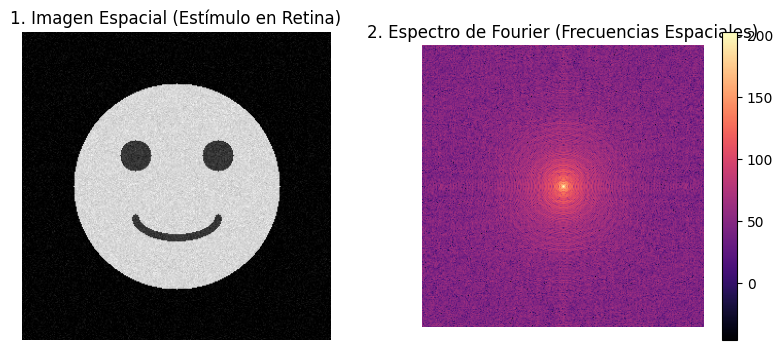

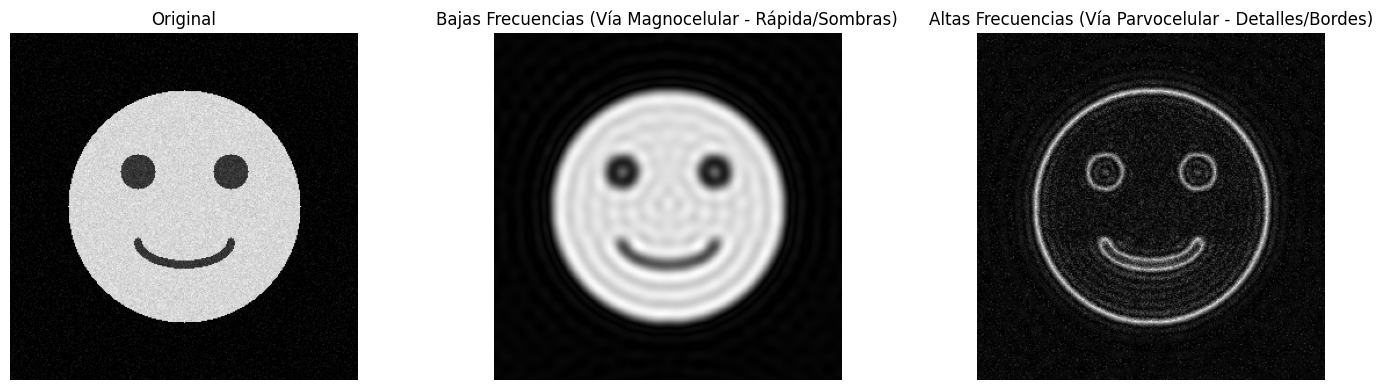

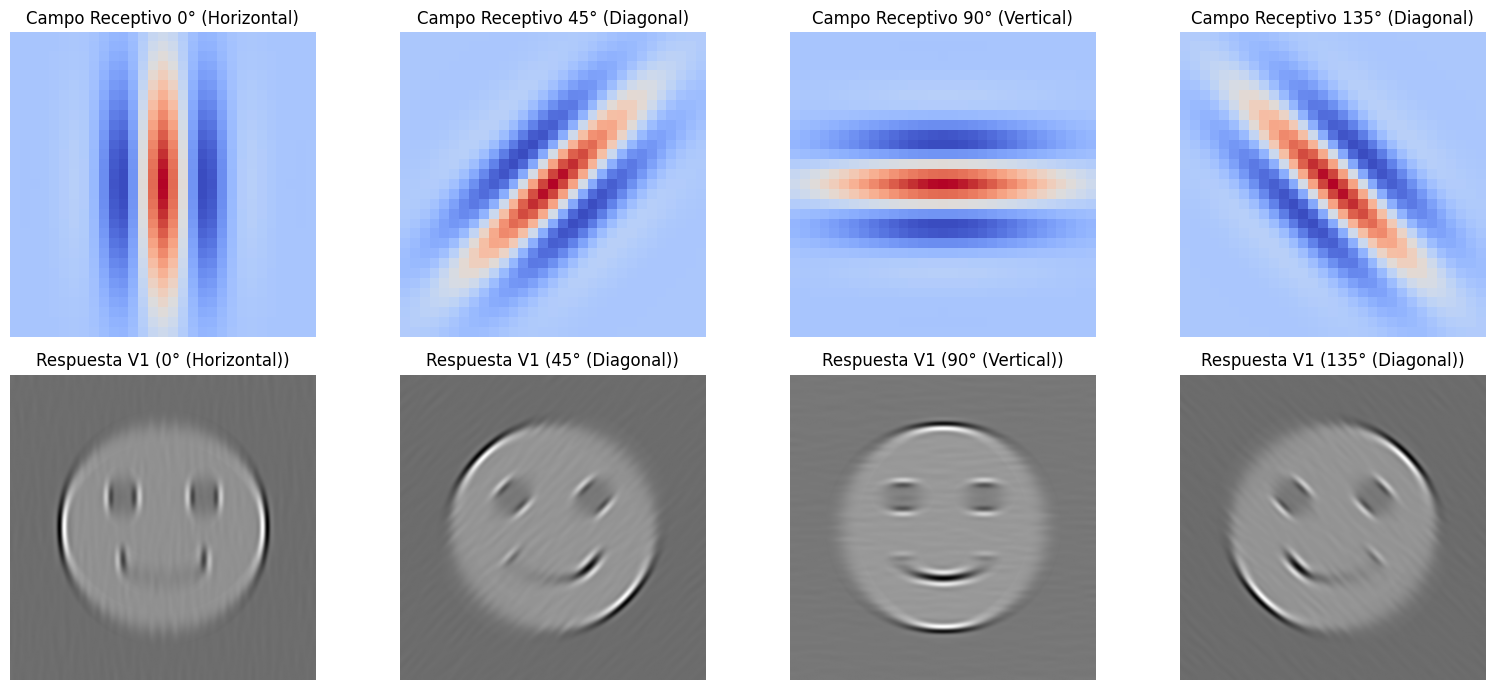

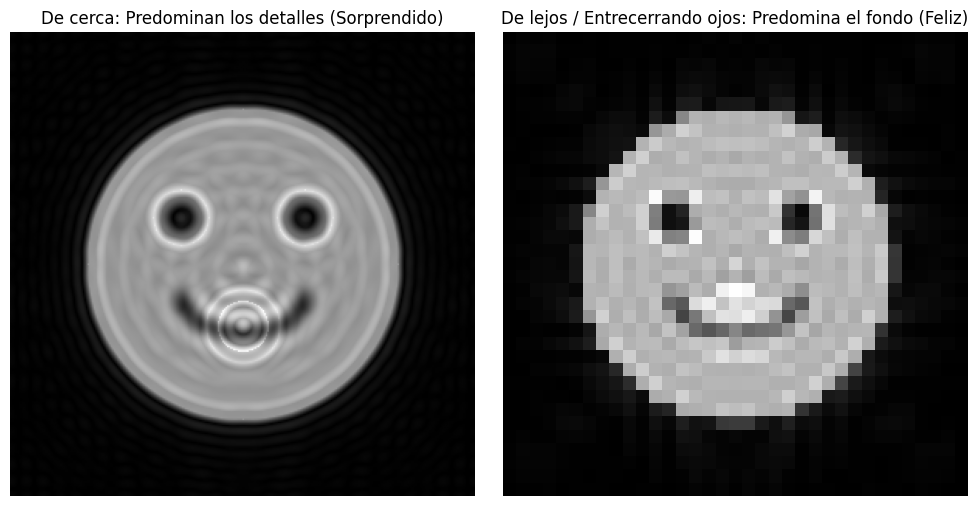

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# ==========================================
# 1. GENERACIÓN DE IMAGEN DE PRUEBA
# ==========================================
def create_synthetic_image():
    h, w = 300, 300
    img = np.zeros((h, w), dtype=np.float32)
    # Rostro esquemático simple con bordes e iluminaciones
    cv2.circle(img, (150, 150), 100, 0.8, -1)
    cv2.circle(img, (110, 120), 15, 0.2, -1)
    cv2.circle(img, (190, 120), 15, 0.2, -1)
    cv2.ellipse(img, (150, 180), (40, 20), 0, 0, 180, 0.2, 5)
    # Ruido para simular textura / altas frecuencias
    noise = np.random.normal(0, 0.04, (h, w))
    img = np.clip(img + noise, 0, 1)
    return img

image = create_synthetic_image()

# ==========================================
# 2. ESPECTRO DE FOURIER (2D)
# ==========================================
f_transform = np.fft.fft2(image)
f_shift = np.fft.fftshift(f_transform)
magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1e-8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('1. Imagen Espacial (Estímulo en Retina)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(magnitude_spectrum, cmap='magma')
plt.title('2. Espectro de Fourier (Frecuencias Espaciales)')
plt.colorbar()
plt.axis('off')
plt.show()

# ==========================================
# 3. VÍA MAGNOCELULAR VS. PARVOCELULAR
# ==========================================
rows, cols = image.shape
crow, ccol = rows // 2 , cols // 2

# Filtro Pasa-Bajos
mask_low = np.zeros((rows, cols), np.float32)
r_low = 20
y, x = np.ogrid[:rows, :cols]
mask_area_low = (x - ccol)**2 + (y - crow)**2 <= r_low**2
mask_low[mask_area_low] = 1

mask_high = 1 - mask_low

# Reconstrucción
img_low = np.abs(np.fft.ifft2(np.fft.ifftshift(f_shift * mask_low)))
img_high = np.abs(np.fft.ifft2(np.fft.ifftshift(f_shift * mask_high)))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_low, cmap='gray')
axes[1].set_title('Bajas Frecuencias (Vía Magnocelular - Rápida/Sombras)')
axes[1].axis('off')

axes[2].imshow(img_high, cmap='gray')
axes[2].set_title('Altas Frecuencias (Vía Parvocelular - Detalles/Bordes)')
axes[2].axis('off')
plt.tight_layout()
plt.show()

# ==========================================
# 4. FILTROS DE GABOR (CORTEZA VISUAL V1)
# ==========================================
angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
labels = ['0° (Horizontal)', '45° (Diagonal)', '90° (Vertical)', '135° (Diagonal)']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, (theta, label) in enumerate(zip(angles, labels)):
    kernel = cv2.getGaborKernel((31, 31), 4.0, theta, 10.0, 0.5, 0, ktype=cv2.CV_32F)
    filtered_img = cv2.filter2D(image, cv2.CV_32F, kernel)

    # Mostrar el Kernel (Campo Receptivo Cortical)
    axes[0, i].imshow(kernel, cmap='coolwarm')
    axes[0, i].set_title(f'Campo Receptivo {label}')
    axes[0, i].axis('off')

    # Respuesta Cortical
    axes[1, i].imshow(filtered_img, cmap='gray')
    axes[1, i].set_title(f'Respuesta V1 ({label})')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# ==========================================
# 5. CURIOSIDAD: IMAGEN HÍBRIDA (ILUSIÓN VISUAL)
# ==========================================
# Rostro Feliz (Bajas Frecuencias)
happy = np.zeros((300, 300), dtype=np.float32)
cv2.circle(happy, (150, 150), 100, 0.8, -1)
cv2.circle(happy, (110, 120), 12, 0.1, -1)
cv2.circle(happy, (190, 120), 12, 0.1, -1)
cv2.ellipse(happy, (150, 170), (40, 25), 0, 0, 180, 0.1, 5)

# Rostro Sorprendido (Altas Frecuencias)
surprised = np.zeros((300, 300), dtype=np.float32)
cv2.circle(surprised, (150, 150), 100, 0.8, -1)
cv2.circle(surprised, (110, 120), 18, 0.1, -1)
cv2.circle(surprised, (190, 120), 18, 0.1, -1)
cv2.circle(surprised, (150, 190), 20, 0.1, 5)

f_happy = np.fft.fftshift(np.fft.fft2(happy))
f_surprised = np.fft.fftshift(np.fft.fft2(surprised))

happy_low = np.abs(np.fft.ifft2(np.fft.ifftshift(f_happy * mask_low)))
surprised_high = np.abs(np.fft.ifft2(np.fft.ifftshift(f_surprised * mask_high)))

hybrid = happy_low + surprised_high

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(hybrid, cmap='gray')
axes[0].set_title('De cerca: Predominan los detalles (Sorprendido)')
axes[0].axis('off')

axes[1].imshow(cv2.resize(hybrid, (35, 35)), cmap='gray')
axes[1].set_title('De lejos / Entrecerrando ojos: Predomina el fondo (Feliz)')
axes[1].axis('off')
plt.tight_layout()
plt.show()